# Python Lesson 49: Probability Distributions and Sampling

**Concept page:** `wiki/concepts/probability-distributions-and-sampling.md` · **Area:** probability

**You will be able to:**
- write pdf/pmf functions for uniform, Gaussian, binomial
- sample by inverse CDF
- estimate parameters from samples

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. PDF / PMF

In [2]:
from math import comb
def unif_pdf(x,a,b): return np.where((x>=a)&(x<=b),1/(b-a),0.)
def gauss_pdf(x,mu,s): return np.exp(-(x-mu)**2/(2*s**2))/(s*np.sqrt(2*np.pi))
def binom_pmf(k,n,p): return comb(n,k)*p**k*(1-p)**(n-k)
x=np.linspace(-4,4,9); print(np.round(gauss_pdf(x,0,1),4)); print(binom_pmf(3,10,0.5))

[0.0001 0.0044 0.054  0.242  0.3989 0.242  0.054  0.0044 0.0001]
0.1171875


## 2. Inverse-CDF sampling

In [3]:
from scipy.stats import norm, binom
rng=np.random.default_rng(0); u=rng.random(100000)
g=norm.ppf(u,loc=10,scale=5); bsamp=binom.ppf(u,20,0.3)
print(g.mean(),g.std(), bsamp.mean(), bsamp.std(), 20*.3, np.sqrt(20*.3*.7))

9.9924539423021 4.995445829139413 5.99701 2.0485021503283805 6.0 2.0493901531919194


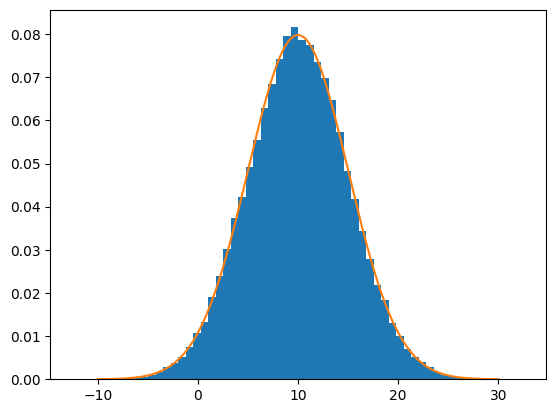

In [4]:
plt.hist(g,bins=60,density=True); xs=np.linspace(-10,30,200); plt.plot(xs,gauss_pdf(xs,10,5)); plt.show()

## 3. Estimating parameters (maximum likelihood)

In [5]:
data=rng.normal(3,2,5000); print(data.mean(), data.std(ddof=1))
flips=rng.random(1000)<0.7; print(flips.mean())

3.040087548571024 2.0125074379658345
0.687


## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
Grade 12 advanced ch. 6 (binomial law) provides binom_pmf; the Grade 9 mean lesson provides the sample mean.

In [6]:
print(binom_pmf(2,4,2/3))

0.29629629629629634


## Exercises

**Exercise 1.** Generate 10000 uniform(2,5) samples by inverse CDF (a + (b-a)u) and check mean 3.5.

In [7]:
# your code here

**Exercise 2.** Check binomial pmf sums to 1 for n=12,p=0.4.

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
s=2+3*rng.random(10000); print(s.mean()); assert abs(s.mean()-3.5)<0.05

3.48671933857048


In [10]:
# Solution 2
assert np.isclose(sum(binom_pmf(k,12,0.4) for k in range(13)),1)